In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression


In [2]:
training_set = pd.read_csv('/Users/alexren/Desktop/UC Davis/ECS 171/Project/features_train.csv')
validation_set = pd.read_csv('/Users/alexren/Desktop/UC Davis/ECS 171/Project/features_val.csv')
test_set = pd.read_csv('/Users/alexren/Desktop/UC Davis/ECS 171/Project/features_test.csv')

In [3]:
training_set.head()

,statement,status,tfidf_vec,count_vec,bert_features,first_person_ratio,negatives_ratio,suicide_ratio,reps_ratio,character_count,word_count,avg_word_length,avg_sentence_length_in_words,avg_sentence_length_in_characters,sia_sentiment
0,to put some context i have been though some th...,suicidal,[0.04838083 0. 0. 0.02265681 0...,[ 1 0 0 1 0 0 0 0 0 0 0 1 1 0 0 ...,"tensor([ 1.1332e-01, -3.2757e-02, 9.6535e-02,...",0.154242,0.007712,0.017995,0.562982,1871,389,3.812339,389.0,1871.0,-0.9686
1,michaelgrainger scyranth gigglessssssss yall a...,normal,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,"tensor([-2.6322e-01, 3.6765e-02, -1.6883e-02,...",0.000000,0.000000,0.000000,0.000000,61,6,9.333333,6.0,61.0,0.0000
2,so right now they are planning to meet at the ...,suicidal,[0. 0. 0. 0. 0...,[ 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"tensor([ 1.1049e-01, 7.6769e-02, 1.9305e-01,...",0.120690,0.043103,0.017241,0.431034,517,116,3.465517,116.0,517.0,-0.9249
3,being broke is no fun,normal,[0. 0. 0. 0. 0...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,"tensor([-1.9146e-02, -3.7258e-02, -4.3136e-03,...",0.000000,0.200000,0.000000,0.000000,21,5,3.400000,5.0,21.0,-0.1779
4,you dont need to worry about that,normal,[0. 0. 0. 0.26469062 0...,[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,"tensor([-6.5769e-02, 4.1372e-02, -1.1422e-01,...",0.000000,0.000000,0.000000,0.000000,33,7,3.857143,7.0,33.0,0.3412


In [4]:
train_xgb = training_set[training_set['status'] != 'normal'].copy()
train_xgb = train_xgb.drop(columns=['tfidf_vec', 'count_vec', 'bert features'], errors='ignore')

In [5]:
val_xgb = validation_set[validation_set['status'] != 'normal'].copy()
val_xgb = val_xgb.drop(columns=['tfidf_vec', 'count_vec', 'bert features'], errors='ignore')

In [6]:
test_xgb = test_set[test_set['status'] != 'normal'].copy()
test_xgb = test_xgb.drop(columns=['tfidf_vec', 'count_vec', 'bert features'], errors='ignore')

In [7]:
le = LabelEncoder()
y_train = le.fit_transform(train_xgb['status'])
y_val = le.transform(val_xgb['status'])
y_test = le.transform(test_xgb['status'])

In [8]:
num_features = train_xgb.select_dtypes(include=[np.number]).columns.tolist()
num_features

features = num_features + ['statement']

In [9]:
X_train = train_xgb[features]
X_val = val_xgb[features]
X_test = test_xgb[features]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=5, max_df = 0.85), 'statement'),
        ('num', 'passthrough', num_features)
    ])

In [11]:
X_train_fit = preprocessor.fit_transform(X_train)
X_val_fit = preprocessor.transform(X_val)
X_test_fit = preprocessor.transform(X_test)

In [12]:
classes = np.unique(y_train)

weights = class_weight.compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Printing out the weights
class_weights_dict = dict(enumerate(weights))

class_names = le.inverse_transform(classes)

print("--- Abnormal Class Weights ---")
for i, name in enumerate(class_names):
    weight = weights[i]
    print(f"Class {classes[i]} ({name}): {weight:.2f}")

--- Abnormal Class Weights ---
Class 0 (anxiety): 0.57
Class 1 (bipolar): 0.57
Class 2 (depression): 2.34
Class 3 (personality disorder): 0.57
Class 4 (stress): 0.57
Class 5 (suicidal): 1.58


In [20]:
custom_weights = {
    'anxiety': 1.5,
    'bipolar': 2.0,
    'depression': 1.0,
    'personality disorder': 3.0,
    'stress': 2.0,
    'suicidal': 1.2
}

sample_weights = train_xgb['status'].map(custom_weights).values

In [13]:
xgb_model = XGBClassifier(
    num_class = len(classes),
    objective = 'multi:softprob',
    n_estimators = 1000,# 200,
    learning_rate = 0.05,
    max_depth = 8,
    subsample = 0.8,
    colsample_bytree = 0.8,
    early_stopping_rounds = 15, 
    gamma = 0.1,
    min_child_weight = 3,
    reg_lambda = 2
)

In [14]:
xgb_model.fit(X_train_fit, y_train, sample_weight=sample_weights, eval_set=[(X_train_fit, y_train), (X_val_fit, y_val)])

[0]	validation_0-mlogloss:1.44825	validation_1-mlogloss:1.45336
[1]	validation_0-mlogloss:1.40474	validation_1-mlogloss:1.41368
[2]	validation_0-mlogloss:1.36602	validation_1-mlogloss:1.37831
[3]	validation_0-mlogloss:1.32872	validation_1-mlogloss:1.34446
[4]	validation_0-mlogloss:1.29617	validation_1-mlogloss:1.31533
[5]	validation_0-mlogloss:1.26432	validation_1-mlogloss:1.28681
[6]	validation_0-mlogloss:1.23403	validation_1-mlogloss:1.26072
[7]	validation_0-mlogloss:1.20638	validation_1-mlogloss:1.23604
[8]	validation_0-mlogloss:1.18109	validation_1-mlogloss:1.21330
[9]	validation_0-mlogloss:1.15735	validation_1-mlogloss:1.19280
[10]	validation_0-mlogloss:1.13352	validation_1-mlogloss:1.17225
[11]	validation_0-mlogloss:1.11184	validation_1-mlogloss:1.15348
[12]	validation_0-mlogloss:1.09125	validation_1-mlogloss:1.13555
[13]	validation_0-mlogloss:1.07204	validation_1-mlogloss:1.11926
[14]	validation_0-mlogloss:1.05336	validation_1-mlogloss:1.10348
[15]	validation_0-mlogloss:1.03524	

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,15
,enable_categorical,False
,eval_metric,None


In [15]:
y_val_pred = xgb_model.predict(X_val_fit)
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

                      precision    recall  f1-score   support

             anxiety       0.83      0.82      0.83       576
             bipolar       0.89      0.75      0.82       416
          depression       0.76      0.75      0.76      2311
personality disorder       0.83      0.64      0.72       162
              stress       0.72      0.72      0.72       388
            suicidal       0.69      0.75      0.72      1598

            accuracy                           0.75      5451
           macro avg       0.79      0.74      0.76      5451
        weighted avg       0.76      0.75      0.75      5451



In [16]:
results = xgb_model.evals_result()
results

{'validation_0': OrderedDict([('mlogloss',
               [1.4482472718399375,
                1.4047355795828946,
                1.3660154495154524,
                1.3287224225708103,
                1.2961696529537463,
                1.2643236728336174,
                1.2340329564073247,
                1.2063757454609416,
                1.181085742608165,
                1.1573480881667395,
                1.1335235199059006,
                1.1118429390598457,
                1.0912549578791089,
                1.072036783044997,
                1.053357921486841,
                1.035241313241182,
                1.0180081583443519,
                1.0021395110698743,
                0.9865924254912759,
                0.9715106884408042,
                0.9568436905111339,
                0.9435300491170269,
                0.9303926760215094,
                0.9175169987111632,
                0.905732913142828,
                0.893808264526102,
                0.882244459

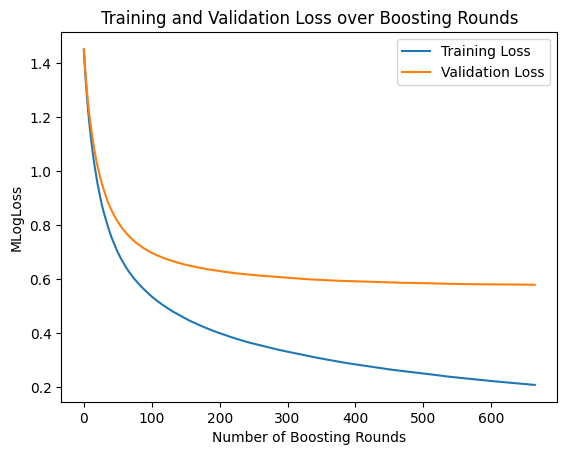

In [17]:
# Training and Validation Loss Plot

plt.plot(results['validation_0']['mlogloss'], label='Training Loss')
plt.plot(results['validation_1']['mlogloss'], label='Validation Loss')
plt.title('Training and Validation Loss over Boosting Rounds')
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('MLogLoss')
plt.legend()
plt.show()

In [ ]:
# Hyperparameter Tuning w/ Grid Search

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.6, 0.8]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_macro', 
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_fit, y_train, sample_weight=sample_weights)

print(f"Best Params: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")

Fitting 3 folds for each of 162 candidates, totalling 486 fits
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5, subsample=0.8; total time=  17.3s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1, subsample=0.8; total time=  19.6s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1, subsample=0.8; total time=  20.0s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1, subsample=0.8; total time=  20.3s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5, subsample=0.8; total time=  20.7s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=3, subsample=0.8; total time=  22.3s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=3, subsample=0.8; total time=  22.4s
[CV] END colsample_bytree=0.6, gamma=0, learning

In [21]:
xgb_model_2 = XGBClassifier(
    num_class = len(classes),
    objective = 'multi:softprob',
    n_estimators = 1000,
    learning_rate = 0.05,
    max_depth = 7,
    subsample = 0.8,
    colsample_bytree = 0.6,
    early_stopping_rounds = 20, 
    gamma = 0.2,
    min_child_weight = 10,
    reg_lambda = 3,
    n_jobs = -1
)

In [22]:
xgb_model_2.fit(X_train_fit, y_train, sample_weight=sample_weights, eval_set=[(X_train_fit, y_train), (X_val_fit, y_val)])

[0]	validation_0-mlogloss:1.45968	validation_1-mlogloss:1.46259
[1]	validation_0-mlogloss:1.42342	validation_1-mlogloss:1.42964
[2]	validation_0-mlogloss:1.39034	validation_1-mlogloss:1.39979
[3]	validation_0-mlogloss:1.35704	validation_1-mlogloss:1.36840
[4]	validation_0-mlogloss:1.32763	validation_1-mlogloss:1.34141
[5]	validation_0-mlogloss:1.29828	validation_1-mlogloss:1.31416
[6]	validation_0-mlogloss:1.27128	validation_1-mlogloss:1.28953
[7]	validation_0-mlogloss:1.24607	validation_1-mlogloss:1.26599
[8]	validation_0-mlogloss:1.22467	validation_1-mlogloss:1.24645
[9]	validation_0-mlogloss:1.20398	validation_1-mlogloss:1.22777
[10]	validation_0-mlogloss:1.18245	validation_1-mlogloss:1.20799
[11]	validation_0-mlogloss:1.16222	validation_1-mlogloss:1.18929
[12]	validation_0-mlogloss:1.14262	validation_1-mlogloss:1.17130
[13]	validation_0-mlogloss:1.12491	validation_1-mlogloss:1.15524
[14]	validation_0-mlogloss:1.10766	validation_1-mlogloss:1.13946
[15]	validation_0-mlogloss:1.09152	

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,None


In [23]:
y_val_pred_2 = xgb_model_2.predict(X_val_fit)
print(classification_report(y_val, y_val_pred_2, target_names=le.classes_))

                      precision    recall  f1-score   support

             anxiety       0.85      0.83      0.84       576
             bipolar       0.88      0.76      0.81       416
          depression       0.77      0.75      0.76      2311
personality disorder       0.82      0.63      0.71       162
              stress       0.72      0.75      0.73       388
            suicidal       0.70      0.76      0.72      1598

            accuracy                           0.76      5451
           macro avg       0.79      0.75      0.76      5451
        weighted avg       0.76      0.76      0.76      5451



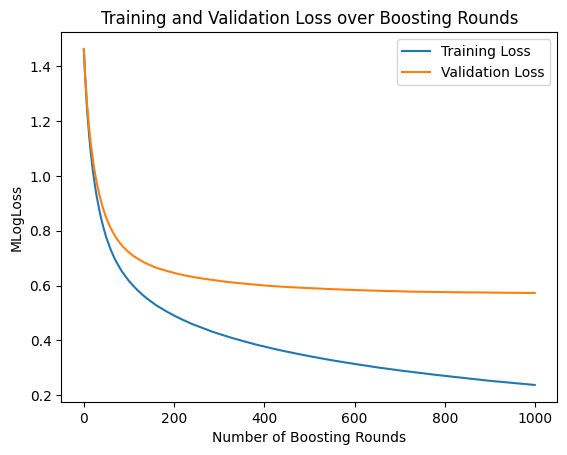

In [24]:
results = xgb_model_2.evals_result()

plt.plot(results['validation_0']['mlogloss'], label='Training Loss')
plt.plot(results['validation_1']['mlogloss'], label='Validation Loss')
plt.title('Training and Validation Loss over Boosting Rounds')
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('MLogLoss')
plt.legend()
plt.show()

In [25]:
y_test_pred_2 = xgb_model_2.predict(X_test_fit)
print(classification_report(y_test, y_test_pred_2, target_names=le.classes_))

                      precision    recall  f1-score   support

             anxiety       0.84      0.84      0.84       576
             bipolar       0.88      0.80      0.84       417
          depression       0.79      0.77      0.78      2311
personality disorder       0.83      0.70      0.76       161
              stress       0.78      0.74      0.76       388
            suicidal       0.71      0.77      0.74      1598

            accuracy                           0.78      5451
           macro avg       0.81      0.77      0.79      5451
        weighted avg       0.78      0.78      0.78      5451



In [29]:
accuracy = accuracy_score(y_test, y_test_pred_2)
print("Final Accuracy:", accuracy)

Final Accuracy: 0.7756374977068428


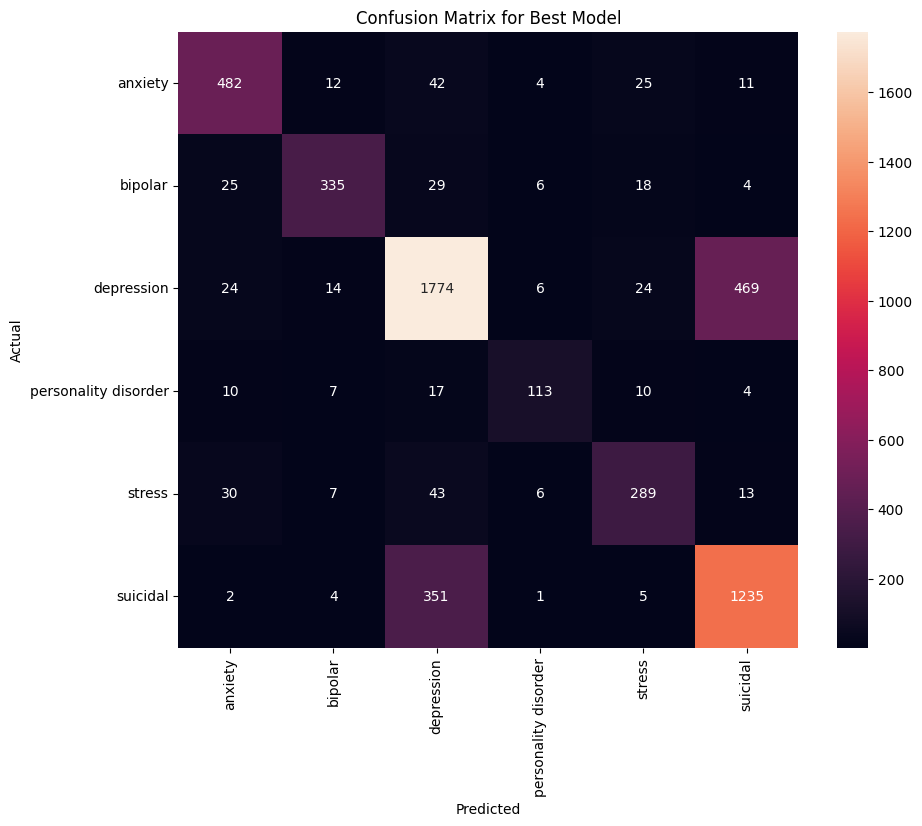

In [26]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_test_pred_2)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()